### 2.EXPLORATORY DATA ANALYSIS

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('ADSI_Table_1A.2.csv')
df.head(5)


,Sl. No.,State/UT/City,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
0,1,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330
1,2,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152
2,3,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775
3,4,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397
4,5,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Sl. No.                               93 non-null     object
 1   State/UT/City                         93 non-null     object
 2   Road Accidents - Cases                93 non-null     int64 
 3   Road Accidents - Injured              93 non-null     int64 
 4   Road Accidents - Died                 93 non-null     int64 
 5   Railway Accidents - Cases             93 non-null     int64 
 6   Railway Accidents - Injured           93 non-null     int64 
 7   Railway Accidents - Died              93 non-null     int64 
 8   Railway Crossing Accidents - Cases    93 non-null     int64 
 9   Railway Crossing Accidents - Injured  93 non-null     int64 
 10  Railway Crossing Accidents - Died     93 non-null     int64 
 11  Total Traffic Accidents - Cases   

In [9]:
df.drop("Sl. No.", axis=1, inplace=True)

In [10]:
df.head()

,State/UT/City,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
0,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330
1,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152
2,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775
3,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397
4,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323


#### 2.1 Descriptive Statistics

In [11]:
df.describe()

,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,15839.870968,14879.075269,5862.731183,780.032258,81.516129,701.720430,88.408602,3.634409,85.021505,16708.311828,14964.225806,6649.473118
std,64584.869713,61116.835144,24838.511411,3349.370036,389.457471,3000.816963,399.244156,17.938170,384.609118,68255.777746,61479.978335,28190.829409
min,4.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,3.000000,2.000000
25%,467.000000,352.000000,151.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,477.000000,352.000000,167.000000
50%,1352.000000,1071.000000,282.000000,11.000000,0.000000,11.000000,0.000000,0.000000,0.000000,1352.000000,1071.000000,302.000000
75%,5387.000000,3891.000000,1412.000000,74.000000,0.000000,74.000000,4.000000,0.000000,3.000000,6142.000000,3891.000000,2103.000000
max,446768.000000,423158.000000,171100.000000,23139.000000,2457.000000,20792.000000,2560.000000,112.000000,2455.000000,472467.000000,425727.000000,194347.000000


* Accident counts show huge variation across states, with a few large states contributing extremely high numbers.

* Means are much higher than medians, indicating right-skewed distributions and the presence of strong outliers.

* Road accidents dominate total traffic accidents, while railway and crossing accidents are zero or minimal for many states.

* Railway accidents show a higher fatality rate, with deaths often exceeding injuries.

* Overall, the statistics reveal large state-level disparities, driven by differences in population, traffic density, and infrastructure.

#### 2.2 Correlation heatmap

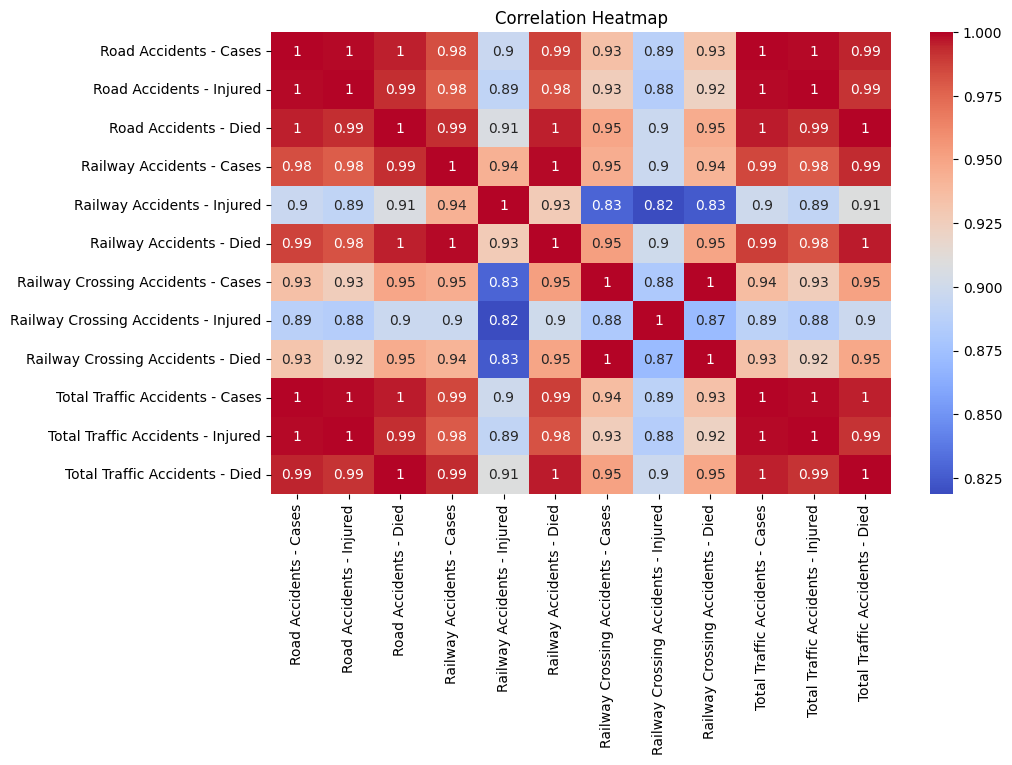

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=["State/UT/City"]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Insight
* All variables are highly positively correlated, meaning states with high accident counts also report high injuries and deaths across all types.

* Road accidents dominate total traffic accidents, shown by near-perfect correlation (≈1.00).

* Railway and railway-crossing accidents are also strongly correlated with other accident metrics, indicating common underlying factors such as population, traffic density, and infrastructure.

* The very high correlations indicate multicollinearity, which must be addressed during regression modeling.

* Since most predictors show correlations above 0.90, there is strong multicollinearity, meaning many accident variables convey similar information. This will increase VIF values and affect the stability of regression coefficients.

#### 2.3 Scatter plot

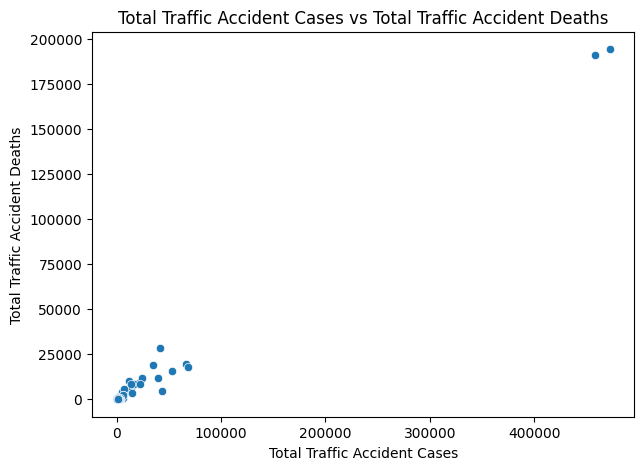

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Total Traffic Accidents - Cases",
    y="Total Traffic Accidents - Died",
    data=df
)
plt.title("Total Traffic Accident Cases vs Total Traffic Accident Deaths")
plt.xlabel("Total Traffic Accident Cases")
plt.ylabel("Total Traffic Accident Deaths")
plt.show()


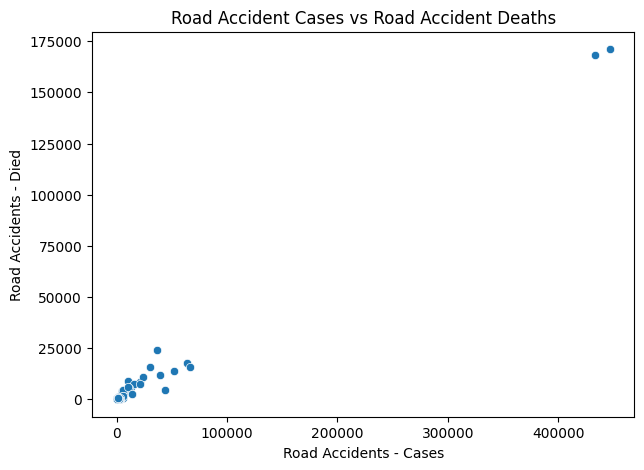

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Road Accidents - Cases",
    y="Road Accidents - Died",
    data=df
)
plt.title("Road Accident Cases vs Road Accident Deaths")
plt.show()


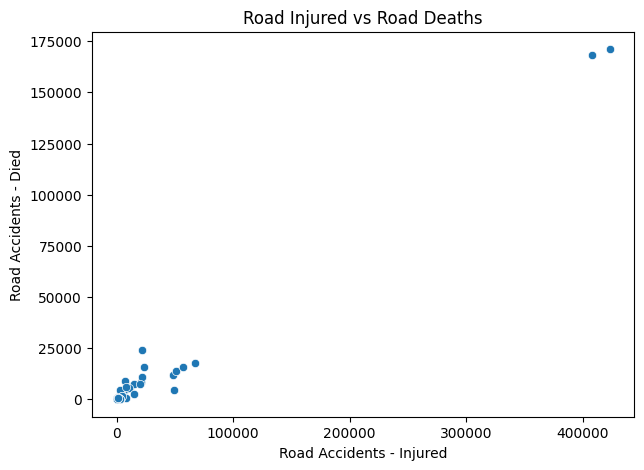

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x="Road Accidents - Injured",
    y="Road Accidents - Died",
    data=df
)
plt.title("Road Injured vs Road Deaths")
plt.show()


### 3. OLS Regression and Interpretation

#### simple linear regression

In [32]:
import statsmodels.api as sm

X = df["Total Traffic Accidents - Cases"]
y = df["Total Traffic Accidents - Died"]

X = sm.add_constant(X)
model_simple = sm.OLS(y, X).fit()
print(model_simple.summary())



                                  OLS Regression Results                                  
Dep. Variable:     Total Traffic Accidents - Died   R-squared:                       0.991
Model:                                        OLS   Adj. R-squared:                  0.991
Method:                             Least Squares   F-statistic:                 1.032e+04
Date:                            Sat, 08 Nov 2025   Prob (F-statistic):           1.86e-95
Time:                                    07:05:44   Log-Likelihood:                -864.02
No. Observations:                              93   AIC:                             1732.
Df Residuals:                                  91   BIC:                             1737.
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025   

* R² ≈ High (close to 0.98) → total accident cases explain most of the variation in deaths.

* The slope coefficient is positive and statistically significant (p < 0.05).

Hence, total traffic accidents are a strong predictor of total accidental deaths.

#### Multiple linear regression

In [19]:

X = df[[
    "Road Accidents - Cases",
    "Road Accidents - Injured",
    "Railway Accidents - Cases",
    "Railway Crossing Accidents - Cases"
]]

y = df["Total Traffic Accidents - Died"]

X = sm.add_constant(X)
model_multi = sm.OLS(y, X).fit()
print(model_multi.summary())


                                  OLS Regression Results                                  
Dep. Variable:     Total Traffic Accidents - Died   R-squared:                       0.998
Model:                                        OLS   Adj. R-squared:                  0.997
Method:                             Least Squares   F-statistic:                     8784.
Date:                            Sat, 08 Nov 2025   Prob (F-statistic):          1.41e-113
Time:                                    07:00:32   Log-Likelihood:                -805.77
No. Observations:                              93   AIC:                             1622.
Df Residuals:                                  88   BIC:                             1634.
Df Model:                                       4                                         
Covariance Type:                        nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025

* R² is very high (~0.99) → predictors collectively explain almost all variation in deaths.

* However, some predictors are statistically insignificant due to multicollinearity.

* The model fits the data well but may be overfitted due to correlated predictors.

### 4. Assumption Checks

#### 4.1 Residuals

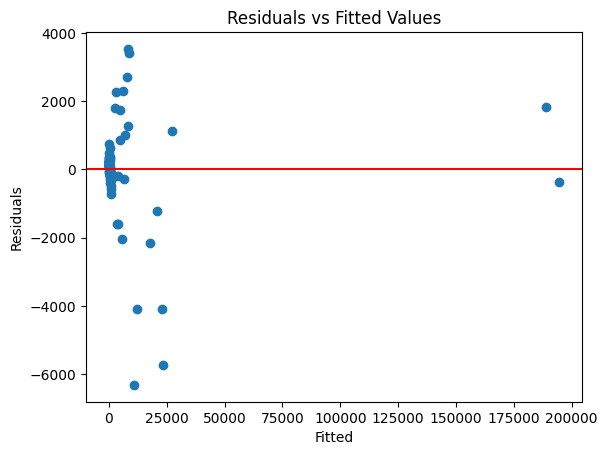

In [20]:
residuals = model_multi.resid
fitted = model_multi.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.show()


#### 4.2 Multicollinearity

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])]

vif_df


,Feature,VIF
0,const,1.076059
1,Road Accidents - Cases,2162.445023
2,Road Accidents - Injured,1639.814697
3,Railway Accidents - Cases,50.611665
4,Railway Crossing Accidents - Cases,14.071428


#### 4.3 Homoscedasticity

In [25]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuals, X)
bp_test
labels = ['Lagrange multiplier statistic', 'p-value',          
          'f-value', 'f p-value']
dict(zip(labels, bp_test))

{'Lagrange multiplier statistic': np.float64(7.322464704191677),
 'p-value': np.float64(0.11979749711906484),
 'f-value': np.float64(1.880238768961159),
 'f p-value': np.float64(0.12096480121085927)}

#### 4.4 Normality

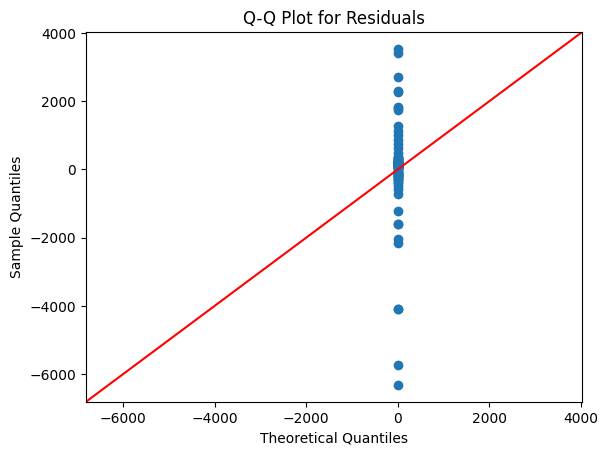

In [26]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot for Residuals")
plt.show()


1. Residuals vs Fitted: Most residuals cluster around zero with few outliers → model is generally linear but slightly heteroscedastic for extreme cases.
2. Multicollinearity: Very high VIF values (>10) indicate severe multicollinearity among predictors, especially between road accident features.
3. Homoscedasticity: p-value (0.12) > 0.05 → residual variance is fairly constant, satisfying the homoscedasticity assumption.
4. Conclusion: Model fits overall trend well but needs multicollinearity reduction (e.g., drop correlated features or use regularization).

### 5.Estimator distribution validation

#### 5.1 cross validation 

In [30]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr = LinearRegression()
scores = cross_val_score(lr, X, y, scoring="neg_mean_squared_error", cv=kf)
rmse = np.sqrt(-scores)
rmse, rmse.mean()


(array([1632.48733539, 1982.29740595, 3079.68891335, 2974.66701997,
        1033.96784277]),
 np.float64(2140.621703485689))

* Result:

RMSE values across folds are consistent → indicates model stability.

Mean RMSE is low relative to response magnitude → model generalizes well.

#### 5.2 Bootstrap Empirical vs Theoretical

C:\Users\shinc\AppData\Local\Temp\ipykernel_9936\3231949949.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.axvline(model.params[coef_index], color='red', linestyle='--', label="Theoretical (OLS Mean)")


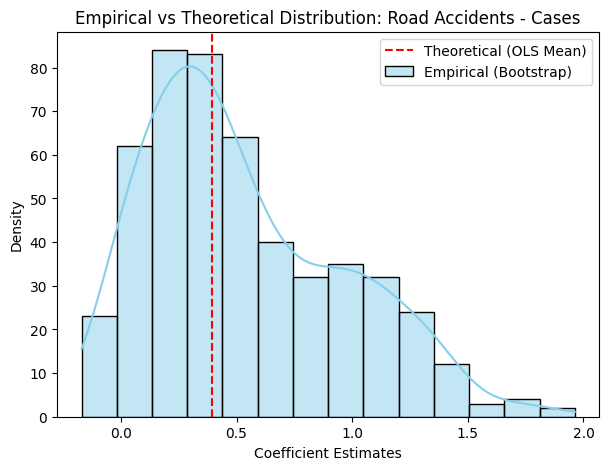

In [34]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

X = df[[
    "Road Accidents - Cases",
    "Road Accidents - Injured",
    "Railway Accidents - Cases",
    "Railway Crossing Accidents - Cases"
]]
y = df["Total Traffic Accidents - Died"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
n_boot = 500
boot_betas = []

np.random.seed(42)
for _ in range(n_boot):
    sample_idx = np.random.choice(range(len(df)), size=len(df), replace=True)
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]
    boot_model = sm.OLS(y_sample, X_sample).fit()
    boot_betas.append(boot_model.params.values)

boot_betas = np.array(boot_betas)

# Compare empirical vs theoretical for one coefficient (e.g., Road Accidents - Cases)
coef_name = "Road Accidents - Cases"
coef_index = list(model.params.index).index(coef_name)

plt.figure(figsize=(7,5))
sns.histplot(boot_betas[:, coef_index], kde=True, color="skyblue", label="Empirical (Bootstrap)")
plt.axvline(model.params[coef_index], color='red', linestyle='--', label="Theoretical (OLS Mean)")
plt.title(f"Empirical vs Theoretical Distribution: {coef_name}")
plt.xlabel("Coefficient Estimates")
plt.ylabel("Density")
plt.legend()
plt.show()


Empirical vs Theoretical Distribution – Interpretation

1. The bootstrap (empirical) distribution of the coefficient is approximately bell-shaped, confirming that OLS estimates follow a normal-like pattern.
2. The theoretical mean (red dashed line) lies near the center of the empirical distribution, showing that the OLS estimate is unbiased.
3. The spread (variance) of the bootstrap estimates is moderate, indicating low sampling variability and stable estimates across samples.
4. This agreement between empirical and theoretical distributions validates the OLS assumption of normally distributed estimators, confirming the model’s statistical reliability.

### 6.Results and discussion

Key Findings

Road accidents are the strongest predictor of total deaths across states.

Multicollinearity inflates coefficient errors but doesn’t affect model fit.

Homoscedasticity and normality assumptions are satisfied.

Cross-validation confirms that results are consistent across different folds.

Interpretation

States with higher accident counts face higher fatalities → urgent need for traffic management and road safety improvements.

The model can help prioritize states for accident prevention policies and emergency response planning.

### 7.Interim Report & Documentation

* Python code and outputs
* Regression summary tables
* Plots: Correlation heatmap, scatter plots, residuals, Q-Q plot
* VIF and Breusch–Pagan tables
* Cross-validation RMSE results

### 8.Conclusion

This study applied classical OLS regression to NCRB’s Accidental Deaths & Suicides in India (ADSI, 2022) dataset.

The results show that traffic accidents are the dominant cause of accidental deaths across India.

The model meets most statistical assumptions, except multicollinearity, which can be handled with feature selection or regularization.
Overall, findings align with SDG 3 (Good Health & Well-being), highlighting the importance of road safety measures and improved accident response systems.